<a href="https://colab.research.google.com/github/sk-shahsi/ML_Model/blob/master/SVM_Support_Vector_Machine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("/content/drug (1).csv")

In [3]:
df

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


Age - Age of patient
Sex - Gender of the Patients
BP - Blood preasure Leavels

Cholestrol - Cholesterol Leavel

Na_to_k - Sodium to potasium Ration in Blood

Droug - Droug Type

In [6]:
df.isnull().sum()

,0
Age,0
Sex,0
BP,0
Cholesterol,0
Na_to_K,0
Drug,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


In [10]:
df.describe(include="O")

,Sex,BP,Cholesterol,Drug
count,200,200,200,200
unique,2,3,2,5
top,M,HIGH,HIGH,DrugY
freq,104,77,103,91


In [11]:
df['BP'].value_counts()

,count
BP,
HIGH,77
LOW,64
NORMAL,59


In [12]:
df['Cholesterol'].value_counts()

,count
Cholesterol,
HIGH,103
NORMAL,97


In [14]:
df['Drug'].value_counts()

,count
Drug,
DrugY,91
drugX,54
drugA,23
drugC,16
drugB,16


In [16]:
l1 = ["Sex","Drug"]
l2 = ["BP","Cholesterol"]

In [23]:
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder

In [20]:
le = LabelEncoder()

In [21]:
for i in l1:
  df[i] = le.fit_transform(df[i])

In [22]:
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,HIGH,HIGH,25.355,0
1,47,1,LOW,HIGH,13.093,3
2,47,1,LOW,HIGH,10.114,3
3,28,0,NORMAL,HIGH,7.798,4
4,61,0,LOW,HIGH,18.043,0


In [24]:
oe = OrdinalEncoder(categories=[["LOW","NORMAL","HIGH"],["NORMAL","HIGH"]])

In [25]:
df[l2] = oe.fit_transform(df[l2])

In [26]:
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,2.0,1.0,25.355,0
1,47,1,0.0,1.0,13.093,3
2,47,1,0.0,1.0,10.114,3
3,28,0,1.0,1.0,7.798,4
4,61,0,0.0,1.0,18.043,0


In [28]:
from sklearn.model_selection import train_test_split

x = df.drop("Drug",axis = 1)
y =df["Drug"]

In [55]:
x.shape


(200, 5)

In [56]:
y.shape

(200,)

In [57]:
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state = 1)

In [58]:
X_test.shape

(40, 5)

In [60]:
y_test.shape

(40,)

In [62]:
X_train.shape

(160, 5)

In [61]:
y_train.shape

(160,)

In [49]:
import seaborn as sns

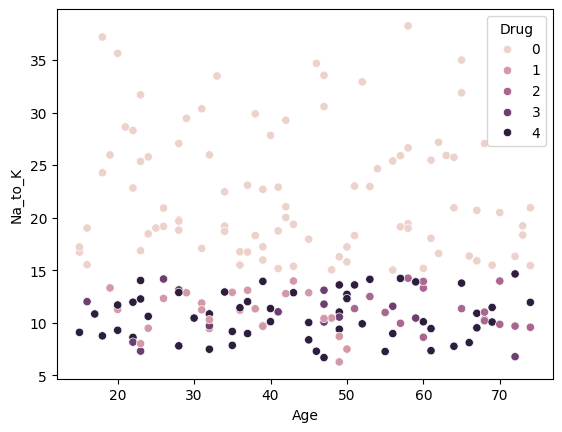

In [50]:
sns . scatterplot(data = df,x="Age",y="Na_to_K",hue="Drug")
plt.show()

In [51]:
from sklearn.svm import SVC

In [52]:
model = SVC(kernel='rbf')

In [63]:
model.fit(X_train,y_train)

SVC()

In [64]:
result = pd.DataFrame()
result["Actual"] = y_test
ypred = model.predict(X_test)
result["Predicted"] = ypred

In [65]:
result

,Actual,Predicted
58,4,4
40,0,0
34,4,0
102,3,4
184,0,0
198,4,4
95,4,4
4,0,0
29,0,0
168,0,0


In [66]:
from sklearn .metrics import *;

In [67]:
accuracy_score(y_test,ypred)

0.725